In [1]:
import time
import matplotlib.pyplot as plt
from DieTesterInstrument import DieTesterStage
from PolarizationController import Keysight8169A
from SantecTunableLaser import TSL770
from Powermeter import KeysightN7749C

In [ ]:
# Connect to the instruments

stg = DieTesterStage()
pol = Keysight8169A()
laser = TSL770()
pm = KeysightN7749C()

In [3]:
########### Initialize the setup ###########

lambda0 = 1.56e-6 # meter, wavelength
laser.wavelength(lambda0);
laser.power_unit('dBm');
laser.power(13); # dBm, max power of Santec TSL770

# Channel 1 for fundamental (InGaAs detector), channel 2 for SHG (Si detector)
pm.wavelength(1,lambda0);
pm.wavelength(2,lambda0/2); # second harmonic
pm.power_unit(1,'dBm');
pm.power_unit(2,'dBm');
pm.averaging_time(1,0.1); # integration time of 0.1 sec
pm.averaging_time(2,1); # integration time of 1 sec, sufficiently long for averaging pol. scramble

pol.set_polarizer_angle(+15); # pol angle that maximizes the output power

In [16]:
#stg.rx(1)
stg.lz(2)

In [4]:
########### Functions ###########

def move_stage(stageaxis, distance):
    match stageaxis:
        case 'lx':
            stg.lx(distance)
        case 'ly':
            stg.ly(distance)
        case 'lz':
            stg.lz(distance)
        case 'rx':
            stg.rx(distance)
        case 'ry':
            stg.ry(distance)
        case 'rz':
            stg.rz(distance)
        case 'mx':
            stg.mx(distance)
        case 'mz':
            stg.mz(distance)

In [ ]:
def scan_power(stageaxis, step, numstep):
    # measure power while scanning a stage along an axis, plot the result
    # stageaxis: stage and orientation, e.g. 'lx'
    # step: distance of each step in micron
    # numstep: single-sided number of steps, thus scans from numstep*step to -numstep*step
    P = []; x = [];
    move_stage(stageaxis, step*numstep) # start from the end of a single side

    i = 0
    while i < numstep*2:
        try:
            x.append( (numstep*2-i)*step );
            i = i+1 
            p = pm.power(1);
            P.append(p);
            print('Scanning ' + stageaxis + ' step ' + str(i) + '/' + str(2*numstep) + ', ' + f"{p:.1f}" + ' dBm', end='\r')
            time.sleep(0.5)
            move_stage(stageaxis,-step)   
        except:
            i = i-1
            
    plt.plot(x,P)
    plt.xlabel('Correction in ' + stageaxis + '(micron)')
    plt.ylabel('Power (dBm)')
    plt.grid(True) 

In [6]:
def maximize_power(stageaxis, step, numstep):
    # optimize the stage position by scanning a stage along an axis
    # stageaxis: stage and orientation, e.g. 'lx'
    # step: distance of each step in micron
    # numstep: single-sided number of steps, thus scans from numstep*step to -numstep*step
    P = [];
    move_stage(stageaxis, step*numstep) # start from the end of a single side

    i = 0
    while i < numstep*2:
        try:
            i = i+1 
            p = pm.power(1);
            P.append(p);
            print('Scanning ' + stageaxis + ' step ' + str(i) + '/' + str(2*numstep) + ', ' + f"{p:.1f}" + ' dBm', end='\r')
            time.sleep(0.5)
            move_stage(stageaxis,-step)   
        except:
            i = i-1
            
    time.sleep(0.5);
    optcomplete = False;
    while not optcomplete:
        try:
            move_stage(stageaxis, (numstep*2 - P.index(max(P))) * step)
            optcomplete = True;
        except:
            optcomplete = False;
    time.sleep(0.5);
    p = pm.power(1);   
    print('Maximized power for axis ' + stageaxis + ' at ' + f"{p:.1f}" + ' dBm', end='\r')

In [7]:
laser.shutter(0); # enable laser emission

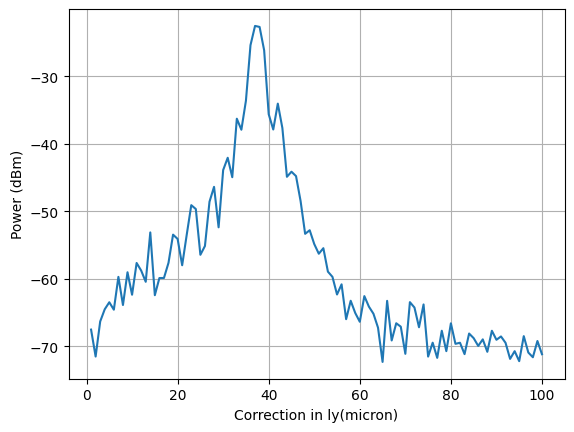

In [ ]:
# Coarse-align y-axis of upstream fiber (left stage)
scan_power('ly', 1, 50) # 1 um step, 50*2 steps

In [9]:
# based on above plot, find the x-value with local max power
# Note: maximum power may not indicate the location of waveguide, but sharp local maximum is more likely the case
# Choose and move to the best ly, argument is micron
stg.ly(38)

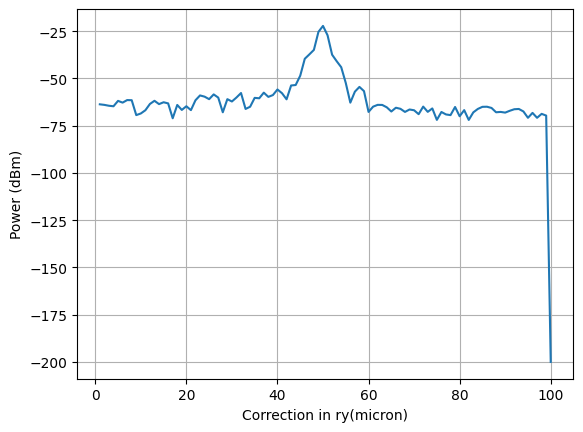

In [10]:
# Coarse-align y-axis of downstream fiber (right stage)
scan_power('ry', 1, 50)

In [11]:
# based on above plot, find the x-value with local max power
# Note: maximum power may not indicate the location of waveguide, but sharp local maximum is more likely the case
# Choose and move to the best ly, argument is micron
stg.ry(49)

In [17]:
# Iterate maximizing power in multiple steps
laser.shutter(0); # laser enabled
pol.set_polarizer_angle(+15) # pol angle that maximizes the output power
steps = [1, 0.5, 0.2, 0.1] # micron, decreasing order

for s in steps:
    maximize_power('lx', s, 5)
    maximize_power('rx', s, 5)
    maximize_power('ly', s, 5)
    maximize_power('ry', s, 5)
    maximize_power('lz', s, 5)
    maximize_power('rz', s, 5)

Stage movement failed: VI_ERROR_TMO (-1073807339): Timeout expired before operation completed.


VisaIOError: VI_ERROR_TMO (-1073807339): Timeout expired before operation completed.

In [18]:
# Output power (dBm), fundamental
pol.set_polarizer_angle(+15) # pol angle that maximizes the output power
laser.shutter(0) # make sure laser is ON
laser.power(13)
pm.power(1)

-13.7161255

In [ ]:
# Switch the powermeter to Si for SHG measurement

In [78]:
# start scramble polarization
pol.scan_sphere()
laser.shutter(0) # make sure laser is ON

In [85]:
stg.rz(-500)

In [21]:
# Output power (dBm), second harmonic
laser.power(13)
pm.power(2)

-82.913147

In [ ]:
#stg.lz(-1000)

In [ ]:
# Finish the measurement
pol.stop_scan()
pol.set_polarizer_angle(+15)
laser.shutter(1) # laser shutter off

In [ ]:
# Make sure InGaAs powermeter connected for next measurement